In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


## Load data

In [2]:
df = pd.read_csv('rishu_customer_segmentation_dataset.csv')
df.head()

,customer_id,age,annual_income,spending_score,visit_frequency
0,1,54,84758.58,15,2
1,2,35,55979.98,2,11
2,3,49,43048.41,72,11
3,4,27,100606.33,50,5
4,5,62,37105.30,17,10


In [3]:
df.describe()

,customer_id,age,annual_income,spending_score,visit_frequency
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,41.413333,55839.348767,50.606667,7.896667
std,86.746758,13.616185,17444.604148,28.319108,3.027078
min,1.000000,18.000000,15000.000000,1.000000,1.000000
25%,75.750000,30.750000,43509.947500,27.000000,6.000000
50%,150.500000,41.000000,54511.795000,51.500000,8.000000
75%,225.250000,52.000000,67792.870000,74.500000,10.000000
max,300.000000,64.000000,104797.890000,99.000000,18.000000


## Feature selection and scaling

In [4]:
features = ['age', 'annual_income', 'spending_score', 'visit_frequency']
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Elbow method to choose k

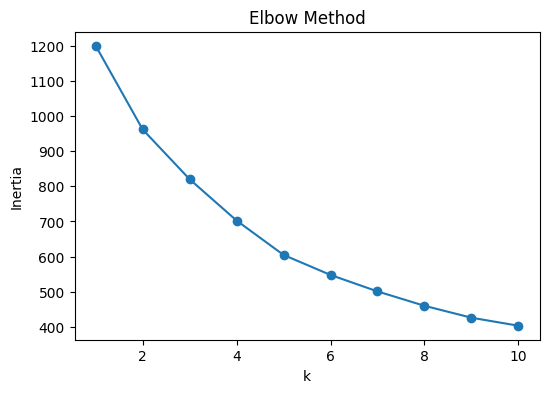

In [5]:
inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

## Fit K-Means

In [6]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)
df.head()

,customer_id,age,annual_income,spending_score,visit_frequency,cluster
0,1,54,84758.58,15,2,2
1,2,35,55979.98,2,11,3
2,3,49,43048.41,72,11,1
3,4,27,100606.33,50,5,3
4,5,62,37105.30,17,10,2


## Visualize clusters

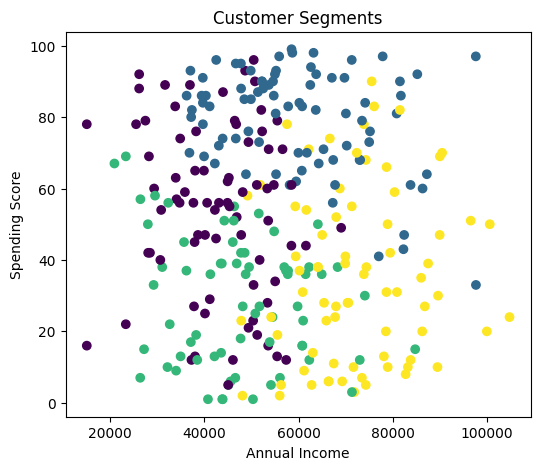

In [7]:
plt.figure(figsize=(6, 5))
plt.scatter(df['annual_income'], df['spending_score'], c=df['cluster'], cmap='viridis')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segments')
plt.show()

## Cluster summary

In [8]:
df.groupby('cluster')[features].mean()

,age,annual_income,spending_score,visit_frequency
cluster,,,,
0,29.289474,42774.905395,54.013158,7.394737
1,50.134146,59840.894634,79.219512,7.085366
2,54.147059,47482.302500,28.632353,7.514706
3,32.500000,72502.187703,35.594595,9.662162
